#### Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn import svm
from sklearn.svm import SVC

plt.rcParams.update({ 'lines.linewidth': 0.8, 'font.size': 14, 'font.family': 'serif','font.serif': ['Times New Roman']})

## Dataset e pré-processamento

In [2]:
df = pd.read_csv('Complete_UPV_Database_raw.csv')
df

,Literature,Specimen ID,Country,Specimen Type,Specimen Age (days),Rebar Present,UPV Device Brand & Model,Transducer Diameter (mm),Transducer Frequency (kHz),Standard,...,Width/Diameter (mm),Max Aggregate Size (mm),W/C Ratio,Strength Class,"Design Strength, fck (MPa)","fc,core (MPa)","fc,ref (MPa)","fc,cyl (MPa)",Notes,Unnamed: 24
0,Cianfrone & Facaoaru (1979),C1_25a,Italy,Cube - Laboratory,1.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,16.08,16.08,13.35,NaN,NaN
1,Cianfrone & Facaoaru (1979),C2_25b,Italy,Cube - Laboratory,2.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,27.95,27.95,23.20,NaN,NaN
2,Cianfrone & Facaoaru (1979),C3_25c,Italy,Cube - Laboratory,7.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,38.64,38.64,32.07,NaN,NaN
3,Cianfrone & Facaoaru (1979),C4_25d,Italy,Cube - Laboratory,28.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,47.86,47.86,39.72,NaN,NaN
4,Cianfrone & Facaoaru (1979),C5_123,Italy,Cube - Laboratory,28.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,56.19,56.19,46.64,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4886,Matthews et al. (2025),F11_41,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,94.0,14.0,NaN,B52.5,45.0,86.00,75.05,63.95,NaN,NaN
4887,Matthews et al. (2025),F11_42,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,94.0,13.0,NaN,B52.5,45.0,76.30,66.59,55.49,NaN,NaN
4888,Matthews et al. (2025),F10_43,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,92.0,10.0,NaN,B52.5,45.0,80.10,69.91,58.81,NaN,NaN
4889,Matthews et al. (2025),F10_44,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,95.0,11.0,NaN,B52.5,45.0,86.30,75.32,64.22,NaN,NaN


In [11]:
# Removendo atributos irrelevantes para a análise e instâncias com valores ausentes
cols_to_drop = [
    'Literature', 'Specimen ID', 'UPV Device Brand & Model', 'Country', 
    'Standard', 'Strength Class', 'W/C Ratio', 'Design Strength, fck (MPa)', 
    'Notes', 'Unnamed: 24', 'fc,core (MPa)', 'fc,ref (MPa)', 
    'Transducer Diameter (mm)',
]

cols_to_dropna = [
    'Specimen Age (days)', 'Transducer Frequency (kHz)', 
    'Max Aggregate Size (mm)', 'Height (mm)', 'Width/Diameter (mm)', 
    'Rebar Present', 'Specimen Type', 'Compression Specimen', 'Test Type', 'fc,cyl (MPa)',
]

df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned = df_cleaned.dropna(subset=cols_to_dropna)

mask_no_rebar = df_cleaned['Rebar Present'].astype(str).str.lower() != 'true'
df_cleaned = df_cleaned[mask_no_rebar]

df_cleaned = df_cleaned.drop(columns=['Rebar Present']).reset_index(drop=True)
df_cleaned

,Specimen Type,Specimen Age (days),Transducer Frequency (kHz),Test Type,No. Tests,"Average Velocity, Vp (m/s)",Compression Specimen,Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),"fc,cyl (MPa)"
0,Cube - Laboratory,1.0,50.0,Direct,3.0,4440,Cube,150.0,150.0,30.0,13.35
1,Cube - Laboratory,2.0,50.0,Direct,3.0,4820,Cube,150.0,150.0,30.0,23.20
2,Cube - Laboratory,7.0,50.0,Direct,3.0,5130,Cube,150.0,150.0,30.0,32.07
3,Cube - Laboratory,28.0,50.0,Direct,3.0,5230,Cube,150.0,150.0,30.0,39.72
4,Cube - Laboratory,28.0,50.0,Direct,3.0,5050,Cube,150.0,150.0,30.0,46.64
...,...,...,...,...,...,...,...,...,...,...,...
1001,Cylinder - In-situ,13880.0,54.0,Direct,1.0,4990,Core,94.0,94.0,14.0,63.95
1002,Cylinder - In-situ,13880.0,54.0,Direct,1.0,4960,Core,94.0,94.0,13.0,55.49
1003,Cylinder - In-situ,13880.0,54.0,Direct,1.0,5090,Core,94.0,92.0,10.0,58.81
1004,Cylinder - In-situ,13880.0,54.0,Direct,1.0,4990,Core,93.0,95.0,11.0,64.22


In [36]:
# Convertendo as colunas categóricas para numéricas
df_cleaned["Specimen Type"] = df_cleaned["Specimen Type"].replace({"Cube - Laboratory": 0, "Element - Laboratory": 1, "Cylinder - Laboratory": 2, "Cylinder - In-situ": 3}).astype(int)
df_cleaned["Compression Specimen"] = df_cleaned["Compression Specimen"].replace({"Cube": 0, "Cylinder": 1, "Core": 2}).astype(int)
df_cleaned["Test Type"] = df_cleaned["Test Type"].replace({"Direct": 0, "Indirect": 1, "Semi-direct": 2}).astype(int)

# Criando intervalos de resistência baseados em fc,cyl (MPa) para classificação
limits = [0, 10, 20, 30, 40, 50, 90, np.inf]
intervals = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-90', '90+']

df_cleaned['Strength_range'] = pd.cut(df_cleaned['fc,cyl (MPa)'], bins=limits, labels=intervals, right=False)
df_labeled = df_cleaned.drop(columns=['fc,cyl (MPa)'])
df_labeled

,Specimen Type,Specimen Age (days),Transducer Frequency (kHz),Test Type,No. Tests,"Average Velocity, Vp (m/s)",Compression Specimen,Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range
0,0,1.0,50.0,0,3.0,4440,0,150.0,150.0,30.0,10-20
1,0,2.0,50.0,0,3.0,4820,0,150.0,150.0,30.0,20-30
2,0,7.0,50.0,0,3.0,5130,0,150.0,150.0,30.0,30-40
3,0,28.0,50.0,0,3.0,5230,0,150.0,150.0,30.0,30-40
4,0,28.0,50.0,0,3.0,5050,0,150.0,150.0,30.0,40-50
...,...,...,...,...,...,...,...,...,...,...,...
1001,3,13880.0,54.0,0,1.0,4990,2,94.0,94.0,14.0,50-90
1002,3,13880.0,54.0,0,1.0,4960,2,94.0,94.0,13.0,50-90
1003,3,13880.0,54.0,0,1.0,5090,2,94.0,92.0,10.0,50-90
1004,3,13880.0,54.0,0,1.0,4990,2,93.0,95.0,11.0,50-90


#### Base de Dados

A base original compreende 5.680 resultados de ensaios de VPU provenientes de 83 estudos publicados, com 20 atributos de entrada e uma variável de saída correspondente à resistência à compressão do concreto ($f_{c,cyl}$). Antes da aplicação dos modelos, foi realizada uma etapa de seleção de atributos, com o objetivo de remover ruído, reduzir a dimensionalidade e garantir a qualidade dos dados, excluindo colunas irrelevantes para a análise (como país do ensaio e equipamento utilizado) e instâncias com valores faltantes. Após esse processo, a base resultante possui 1.005 instâncias e 11 atributos.

As variáveis resultantes estão dispostas na lista a seguir. Os atributos categóricos, originalmente codificados como inteiros, passarão pela técnica de one-hot encoding para serem convertidos em colunas binárias, evitando a imposição de uma ordem artificial entre as categorias.

* Specimen Type (Categórico, 4 valores): Cube - Laboratory (0), Element - Laboratory (1), Cylinder - Laboratory (2), Cylinder - In-situ (3);
* Specimen Age (days);
* Transducer Frequency (kHz);
* Test Type (Categótico, 3 valores): Direct (0), Indirect (1), Semi-direct (2);
* No. Tests;
* Average Velocity, Vp (m/s);
* Compression Specimen (Categórico, 3 valores): Cube (0), Cylinder (1), Core (2);
* Height (mm);
* Width/Diameter (mm);
* Max Aggregate Size (mm);
* Strength_range (target): faixas correspondentes à classe de resistência do concreto '0-10', '10-20', '20-30', '30-40', '40-50', '50-90', '90+'

Referência: MATTHEWS, B.; ALLAIX, D.; WIJTE, S.; VULLINGS, M.. Advancing non-destructive concrete compressive strength estimation: Large-Scale datasets and machine learning framework. **NDT & E International**, v. 158, 103549, 2026. 

In [17]:
# Convertendo as colunas categóricas para numéricas usando one-hot encoding
df_processed= pd.get_dummies(df_labeled, columns=["Specimen Type", "Compression Specimen", "Test Type"])

df_processed

,Specimen Age (days),Transducer Frequency (kHz),No. Tests,"Average Velocity, Vp (m/s)",Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range,Specimen Type_0,Specimen Type_1,Specimen Type_2,Specimen Type_3,Compression Specimen_0,Compression Specimen_1,Compression Specimen_2,Test Type_0,Test Type_1,Test Type_2
0,1.0,50.0,3.0,4440,150.0,150.0,30.0,10-20,True,False,False,False,True,False,False,True,False,False
1,2.0,50.0,3.0,4820,150.0,150.0,30.0,20-30,True,False,False,False,True,False,False,True,False,False
2,7.0,50.0,3.0,5130,150.0,150.0,30.0,30-40,True,False,False,False,True,False,False,True,False,False
3,28.0,50.0,3.0,5230,150.0,150.0,30.0,30-40,True,False,False,False,True,False,False,True,False,False
4,28.0,50.0,3.0,5050,150.0,150.0,30.0,40-50,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,13880.0,54.0,1.0,4990,94.0,94.0,14.0,50-90,False,False,False,True,False,False,True,True,False,False
1002,13880.0,54.0,1.0,4960,94.0,94.0,13.0,50-90,False,False,False,True,False,False,True,True,False,False
1003,13880.0,54.0,1.0,5090,94.0,92.0,10.0,50-90,False,False,False,True,False,False,True,True,False,False
1004,13880.0,54.0,1.0,4990,93.0,95.0,11.0,50-90,False,False,False,True,False,False,True,True,False,False


#### Análise exploratória e métrica dos dados

In [18]:
df_num = df_processed.drop(columns=["Specimen Type", "Test Type", "Compression Specimen"], errors='ignore')
df_num = df_num.select_dtypes(include=['number'])

desc = df_num.agg(["mean", "median", "std", "min", "max"]).T
desc = desc.round(2)
print(desc.to_string())


                               mean  median      std     min      max
Specimen Age (days)          828.17    28.0  3614.66     1.0  24837.0
Transducer Frequency (kHz)    53.71    55.0     2.94    42.5     55.0
No. Tests                      2.62     1.0     2.97     1.0     10.0
Average Velocity, Vp (m/s)  4507.05  4580.0   459.28  1320.0   5390.0
Height (mm)                  122.13   100.0    47.81    65.0    300.0
Width/Diameter (mm)          113.03   100.0    22.50    75.0    150.0
Max Aggregate Size (mm)       16.86    14.0     6.56     5.0     30.0


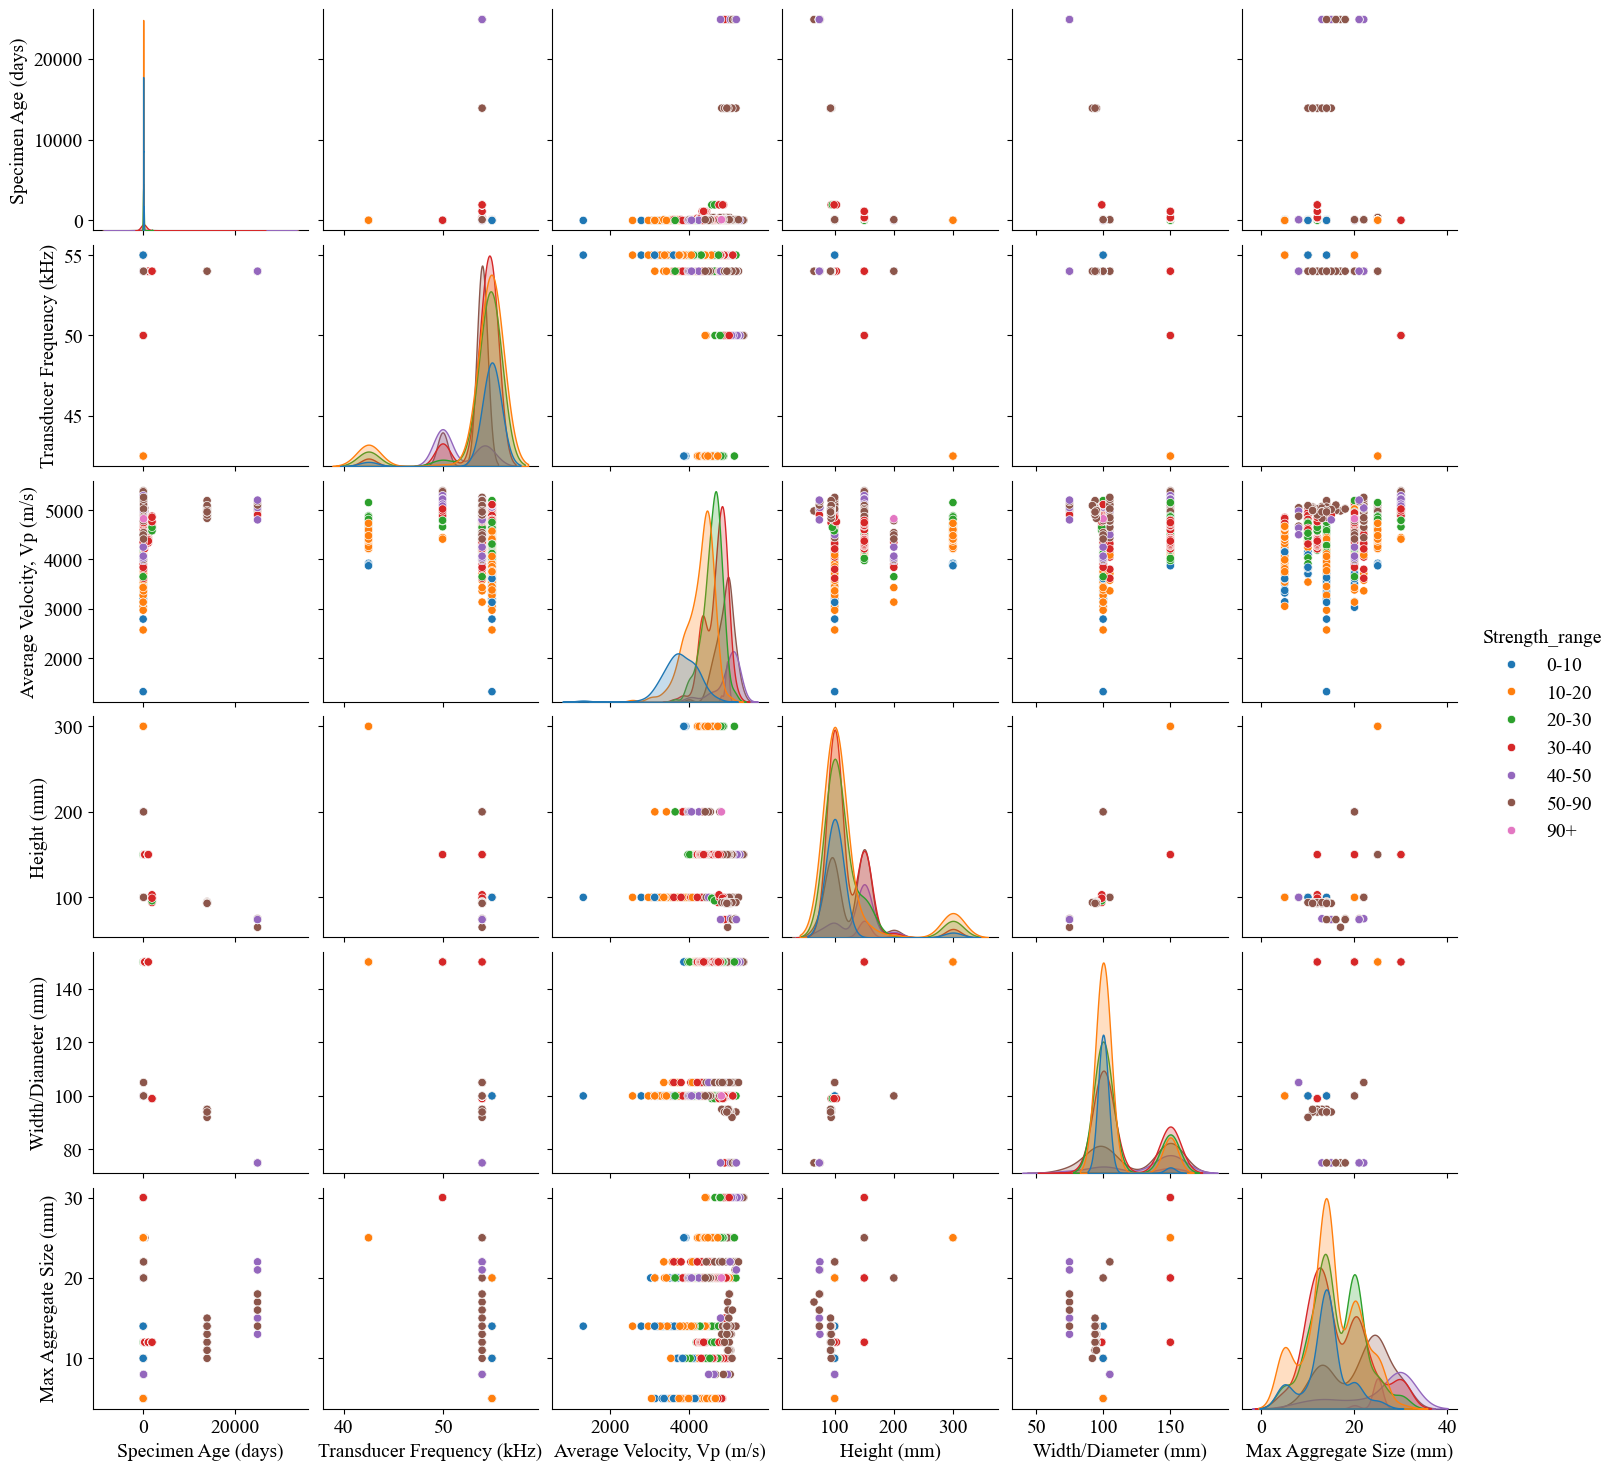

In [19]:
cols = [
    'Specimen Age (days)',
    'Transducer Frequency (kHz)',
    'Average Velocity, Vp (m/s)',
    'Height (mm)',
    'Width/Diameter (mm)',
    'Max Aggregate Size (mm)',
    'Strength_range'
]

sns.pairplot(df_processed[cols], hue='Strength_range')
plt.savefig('relacao_pares.pdf', dpi=600)

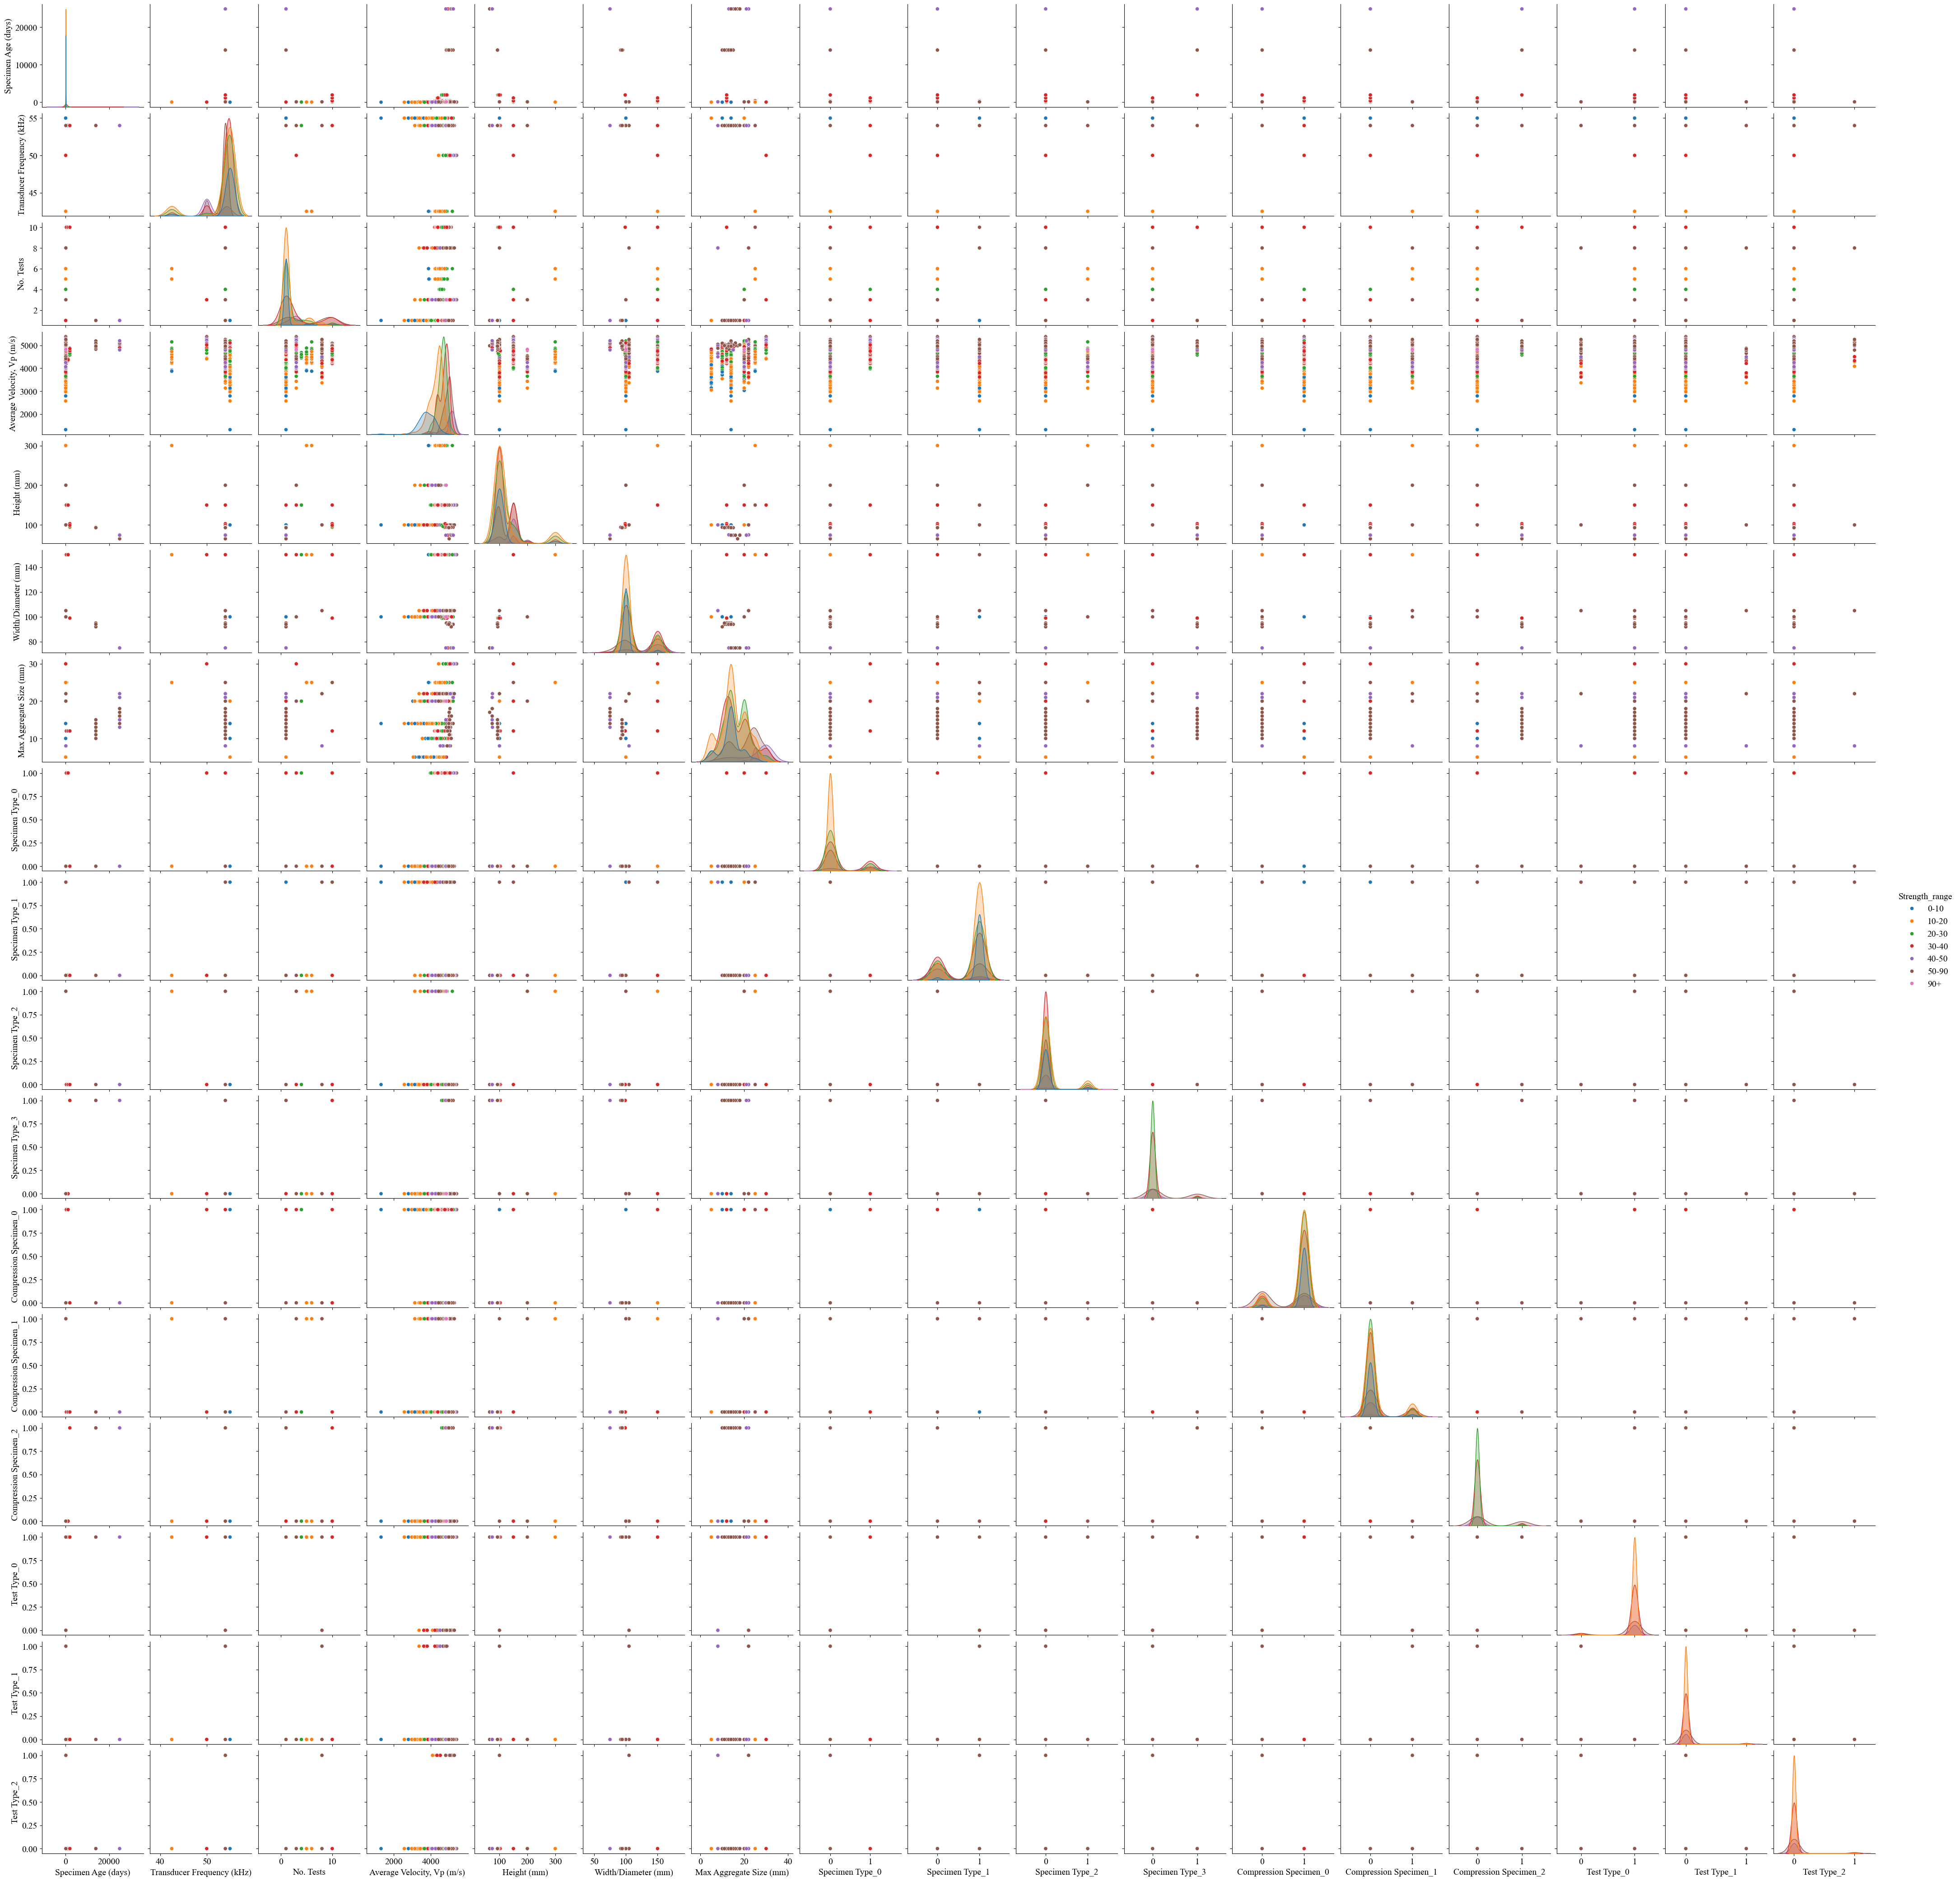

In [20]:
sns.pairplot(df_processed, hue='Strength_range')

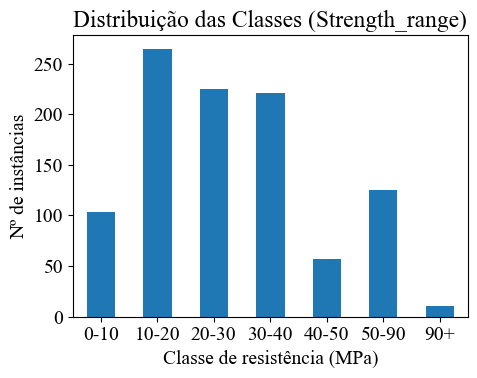

In [21]:
ordem = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-90', '90+']
df_processed['Strength_range'] = pd.Categorical(df_processed['Strength_range'], categories=ordem, ordered=True)
frequencia = df_processed['Strength_range'].value_counts(sort=False)

plt.figure(figsize=(5, 4))
frequencia.plot(kind='bar', edgecolor='None')

plt.title('Distribuição das Classes (Strength_range)')
plt.xlabel('Classe de resistência (MPa)')
plt.ylabel('Nº de instâncias')

plt.xticks(rotation=0) 

plt.tight_layout()
plt.savefig('distribuicao_classes.pdf', dpi=600)

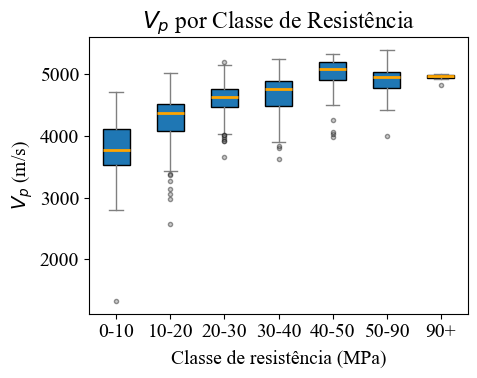

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))

data_by_class = [df_processed.loc[df_processed["Strength_range"] == c, "Average Velocity, Vp (m/s)"].values
                 for c in ordem if c in df_processed["Strength_range"].values]
bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                 medianprops=dict(color='orange', linewidth=2),
                 whiskerprops=dict(color='gray'),
                 capprops=dict(color='gray'),
                 flierprops=dict(marker="o", markersize=3,
                                markerfacecolor='gray', alpha=0.4))

ax.set_xticklabels(ordem)
ax.set_xlabel("Classe de resistência (MPa)", labelpad=6)
ax.set_ylabel("$V_p$ (m/s)")
ax.set_title("$V_p$ por Classe de Resistência")

plt.tight_layout()
plt.savefig('boxplot_classes.pdf', dpi=600)

#### Definindo o conjunto de testes e treino

In [23]:
target = 'Strength_range'
attributes = list(df_processed.columns[(df_processed.columns != target)])

target = df_processed[target].values
attributes = df_processed[attributes].values

X_train, X_test, y_train, y_test = train_test_split(attributes, target, test_size=0.30, random_state=42, stratify=target)


In [24]:
df_train, df_test = train_test_split(df_processed, test_size=0.3, random_state=42)
df_train

,Specimen Age (days),Transducer Frequency (kHz),No. Tests,"Average Velocity, Vp (m/s)",Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range,Specimen Type_0,Specimen Type_1,Specimen Type_2,Specimen Type_3,Compression Specimen_0,Compression Specimen_1,Compression Specimen_2,Test Type_0,Test Type_1,Test Type_2
543,28.0,55.0,1.0,4640,100.0,100.0,10.0,10-20,False,True,False,False,True,False,False,True,False,False
442,60.0,55.0,1.0,4520,100.0,100.0,14.0,10-20,False,True,False,False,True,False,False,True,False,False
915,280.0,54.0,10.0,4292,150.0,150.0,12.0,30-40,True,False,False,False,True,False,False,True,False,False
398,21.0,55.0,1.0,4670,100.0,100.0,14.0,20-30,False,True,False,False,True,False,False,True,False,False
960,91.0,54.0,3.0,4412,200.0,100.0,20.0,50-90,False,False,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,28.0,54.0,10.0,4590,150.0,150.0,25.0,50-90,False,True,False,False,True,False,False,True,False,False
270,21.0,55.0,1.0,4870,100.0,100.0,14.0,20-30,False,True,False,False,True,False,False,True,False,False
860,90.0,54.0,8.0,4759,100.0,105.0,22.0,50-90,False,True,False,False,False,True,False,False,True,False
435,28.0,55.0,1.0,4360,100.0,100.0,14.0,10-20,False,True,False,False,True,False,False,True,False,False


#### Padronização dos dados

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cross_val = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## K-Nearest Neighbors (KNN)

In [30]:
parameters_knn = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), parameters_knn, cv=cross_val, scoring="f1_weighted", n_jobs=-1)

grid_knn.fit(X_train_scaled, y_train)
print(f"F1-score médio CV — KNN: {grid_knn.best_score_:.4f}")
print(f"Desvio padrão CV — KNN:  {grid_knn.cv_results_['std_test_score'][grid_knn.best_index_]:.4f}")
print(grid_knn.best_params_)

knn_best = grid_knn.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))

C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


F1-score médio CV — KNN: 0.5538
Desvio padrão CV — KNN:  0.0403
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
              precision    recall  f1-score   support

        0-10       0.74      0.74      0.74        31
       10-20       0.60      0.66      0.63        80
       20-30       0.53      0.46      0.49        68
       30-40       0.57      0.61      0.59        66
       40-50       0.50      0.35      0.41        17
       50-90       0.74      0.78      0.76        37
         90+       0.50      0.33      0.40         3

    accuracy                           0.61       302
   macro avg       0.60      0.56      0.57       302
weighted avg       0.60      0.61      0.60       302



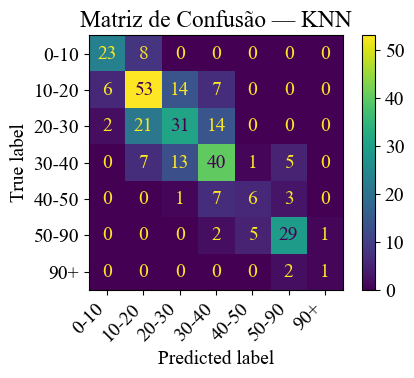

In [31]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=ordem)
fig, ax = plt.subplots(figsize=(5, 4))
disp_knn.plot(ax=ax)
ax.set_title("Matriz de Confusão — KNN")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matriz_confusao_knn.pdf', dpi=600)

In [32]:
# Classificador nulo que apenas chuta uma resposta considerando a distribuições das classes
dummy_clf = DummyClassifier(strategy='stratified')
dummy_clf.fit(X_train_scaled,y_train)
print(classification_report(y_test, dummy_clf.predict(X_test)))

              precision    recall  f1-score   support

        0-10       0.19      0.23      0.21        31
       10-20       0.32      0.36      0.34        80
       20-30       0.25      0.25      0.25        68
       30-40       0.30      0.27      0.29        66
       40-50       0.06      0.06      0.06        17
       50-90       0.13      0.11      0.12        37
         90+       0.00      0.00      0.00         3

    accuracy                           0.25       302
   macro avg       0.18      0.18      0.18       302
weighted avg       0.25      0.25      0.25       302



## Support Vector Machine (SVM)

In [33]:
parameters_svm = {
    "kernel": ["linear", "rbf", "poly"],
    "C"     : [0.1, 1, 10, 100],
    "gamma" : ["scale", "auto", 0.01, 0.1, 1],
}

grid_svm = GridSearchCV(SVC(decision_function_shape='ovr', random_state=42), parameters_svm, cv=cross_val, scoring="f1_weighted", n_jobs=-1)

grid_svm.fit(X_train_scaled, y_train)
print(f"F1-score médio CV — SVM: {grid_svm.best_score_:.4f}")
print(f"Desvio padrão CV — SVM:  {grid_svm.cv_results_['std_test_score'][grid_svm.best_index_]:.4f}")
print(grid_svm.best_params_)

svm_best = grid_svm.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svm))

C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


F1-score médio CV — SVM: 0.6175
Desvio padrão CV — SVM:  0.0595
{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

        0-10       0.82      0.58      0.68        31
       10-20       0.58      0.66      0.62        80
       20-30       0.51      0.51      0.51        68
       30-40       0.62      0.62      0.62        66
       40-50       0.42      0.47      0.44        17
       50-90       0.82      0.76      0.79        37
         90+       0.00      0.00      0.00         3

    accuracy                           0.61       302
   macro avg       0.54      0.52      0.52       302
weighted avg       0.61      0.61      0.61       302



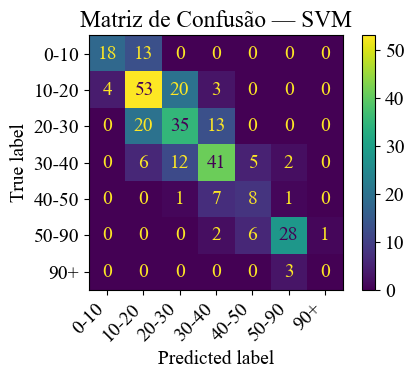

In [34]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=ordem)
fig, ax = plt.subplots(figsize=(5, 4))
disp_svm.plot(ax=ax)
ax.set_title("Matriz de Confusão — SVM")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matriz_confusao_svm.pdf', dpi=600)